# EDA: Omni COCO Dataset — Klasifikasi Maloklusi Gigi

Notebook ini melakukan eksplorasi awal terhadap dataset `omni_coco`, yaitu dataset foto intraoral pasien dalam format COCO (deteksi objek) dengan label kondisi/gigi terkait maloklusi.

**Struktur dataset:**
- `omni_coco/annotations/instances_{train,val,test}.json` — anotasi COCO per split
- `omni_coco/{train,val,test}/<case_id>/<visit_date>/<file_name>.JPG` — gambar, dikelompokkan per pasien (case) dan per kunjungan (visit)

**Tujuan notebook:**
1. Memahami ukuran dan struktur dataset (jumlah pasien, visit, gambar, anotasi)
2. Melihat distribusi kelas (kategori) dan cek imbalance
3. Melihat statistik bounding box
4. Cek integritas data (file hilang, overlap pasien antar split / data leakage)
5. Visualisasi sampel gambar + bounding box

## 1. Setup

In [1]:
import json
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

ROOT = Path("../Dataset/omni_coco")
SPLITS = ["train", "val", "test"]
ANN_DIR = ROOT / "annotations"


## 2. Load anotasi COCO

Setiap file `instances_{split}.json` berisi `info`, `licenses`, `images`, `annotations`, dan `categories` (format COCO standar). Kita load ketiga split ke dict, lalu ubah `images`, `annotations`, dan `categories` masing-masing menjadi DataFrame supaya mudah dianalisis.

In [2]:
raw = {}
for split in SPLITS:
    with open(ANN_DIR / f"instances_{split}.json") as f:
        raw[split] = json.load(f)

categories = pd.DataFrame(raw["train"]["categories"])[["id", "name", "supercategory"]]
cat_id_to_name = dict(zip(categories["id"], categories["name"]))
categories


,id,name,supercategory
0,1,HT,your_super_category
1,2,TT,your_super_category
2,3,DO,your_super_category
3,4,IOA,your_super_category
4,5,TE,your_super_category
5,6,CFOA,your_super_category
6,7,TM,your_super_category
7,8,MR,your_super_category
8,9,OB,your_super_category
9,10,FOD,your_super_category


### Glossary kategori

Kode kategori di atas (`name`) tidak dijelaskan di dalam file COCO-nya sendiri (`info`/`licenses` kosong). Berdasarkan **Table 1 di paper dataset OMNI**, artinya sebagai berikut:

| Kode | Istilah medis |
|---|---|
| HT | Healthy Teeth |
| TT | Tooth Torsion |
| DO | Deep Overjet |
| IOA | Invisible Orthodontic Attachment |
| TE | Tooth Emergence |
| CFOA | Cast Fixed Orthodontic Appliances |
| TM | Tooth Misalignment |
| MR | Mandibular Retrusion |
| OB | Orthodontic Brace |
| FOD | Fixed Orthodontic Device |

Catatan: `OB`, `IOA`, `CFOA`, `FOD` adalah **alat/kondisi terkait perawatan ortodontik** (behel/attachment), bukan semuanya kelainan maloklusi murni — sedangkan `TT`, `DO`, `TM`, `MR` lebih merepresentasikan kondisi/kelainan gigi-rahang, dan `HT`/`TE` merepresentasikan kondisi gigi normal/sedang tumbuh. Perlu dipikirkan apakah kategori "alat" dan "kondisi klinis" ini digabung jadi satu task klasifikasi atau dipisah.

**Soal angka "Quantities" di Table 1 paper vs angka di section 5 notebook ini — sudah diverifikasi cocok:** angka paper menghitung **jumlah gambar unik** yang mengandung minimal satu temuan kategori itu (`nunique(image_id)` per kategori), BUKAN jumlah instance bounding box. Sudah dicek manual dan cocok 1:1 persis untuk semua 10 kategori (mis. HT: paper=3610 = jumlah foto yang punya minimal 1 box HT; sedangkan section 5 di bawah menghitung total box HT di semua foto = 38044, karena rata-rata satu foto oklusal bisa berisi banyak gigi yang sama-sama ditandai HT). Jadi kedua angka itu sama-sama benar, cuma unit hitungnya beda (per-gambar vs per-instance) — bukan indikasi versi/split dataset yang berbeda seperti dugaan awal.

In [3]:
CATEGORY_GLOSSARY = {
    "HT": "Healthy Teeth",
    "TT": "Tooth Torsion",
    "DO": "Deep Overjet",
    "IOA": "Invisible Orthodontic Attachment",
    "TE": "Tooth Emergence",
    "CFOA": "Cast Fixed Orthodontic Appliances",
    "TM": "Tooth Misalignment",
    "MR": "Mandibular Retrusion",
    "OB": "Orthodontic Brace",
    "FOD": "Fixed Orthodontic Device",
}

categories["full_name"] = categories["name"].map(CATEGORY_GLOSSARY)
categories


,id,name,supercategory,full_name
0,1,HT,your_super_category,Healthy Teeth
1,2,TT,your_super_category,Tooth Torsion
2,3,DO,your_super_category,Deep Overjet
3,4,IOA,your_super_category,Invisible Orthodontic Attachment
4,5,TE,your_super_category,Tooth Emergence
5,6,CFOA,your_super_category,Cast Fixed Orthodontic Appliances
6,7,TM,your_super_category,Tooth Misalignment
7,8,MR,your_super_category,Mandibular Retrusion
8,9,OB,your_super_category,Orthodontic Brace
9,10,FOD,your_super_category,Fixed Orthodontic Device


In [4]:
images = {}
annotations = {}

for split in SPLITS:
    imgs = pd.DataFrame(raw[split]["images"])
    imgs["split"] = split
    images[split] = imgs

    anns = pd.DataFrame(raw[split]["annotations"])
    anns["split"] = split
    anns["category_name"] = anns["category_id"].map(cat_id_to_name)
    annotations[split] = anns

images_all = pd.concat(images.values(), ignore_index=True)
annotations_all = pd.concat(annotations.values(), ignore_index=True)

images_all.head()


,id,file_name,width,height,subfolder1,subfolder2,split
0,201801201807301,201801201807301.JPG,512,341,2018.01,2018.07.30,train
1,201801201807302,201801201807302.JPG,512,341,2018.01,2018.07.30,train
2,201801201807303,201801201807303.JPG,512,341,2018.01,2018.07.30,train
3,201801201807304,201801201807304.JPG,512,341,2018.01,2018.07.30,train
4,201801201807305,201801201807305.JPG,512,341,2018.01,2018.07.30,train


In [5]:
annotations_all.head()


,id,image_id,category_id,bbox,area,segmentation,iscrowd,split,category_name
0,1,201801201807301,2,"[119.0, 122.0, 44.0, 62.0]",2728.0,[],0,train,TT
1,2,201801201807301,2,"[259.0, 105.0, 51.0, 71.0]",3621.0,[],0,train,TT
2,3,201801201807301,1,"[32.0, 144.0, 23.0, 34.0]",782.0,[],0,train,HT
3,4,201801201807301,1,"[57.0, 145.0, 17.0, 40.0]",680.0,[],0,train,HT
4,5,201801201807301,1,"[72.0, 138.0, 26.0, 47.0]",1222.0,[],0,train,HT


## 3. Ringkasan dataset per split

Jumlah gambar, anotasi, pasien (case) unik (`subfolder1`), dan visit unik (`subfolder1` + `subfolder2`).

In [6]:
summary_rows = []
for split in SPLITS:
    imgs = images[split]
    anns = annotations[split]
    summary_rows.append({
        "split": split,
        "n_images": len(imgs),
        "n_annotations": len(anns),
        "n_patients": imgs["subfolder1"].nunique(),
        "n_visits": imgs.groupby(["subfolder1", "subfolder2"]).ngroups,
        "avg_images_per_visit": len(imgs) / imgs.groupby(["subfolder1", "subfolder2"]).ngroups,
        "avg_anns_per_image": len(anns) / len(imgs),
    })

summary = pd.DataFrame(summary_rows).set_index("split")
summary


,n_images,n_annotations,n_patients,n_visits,avg_images_per_visit,avg_anns_per_image
split,,,,,,
train,2481,36449,210,547,4.535649,14.691254
val,857,12482,89,191,4.486911,14.564761
test,828,12207,85,184,4.500000,14.742754


Total gabungan (semua split):

In [7]:
print(f"Total gambar : {len(images_all)}")
print(f"Total anotasi: {len(annotations_all)}")
print(f"Total pasien : {images_all['subfolder1'].nunique()}")


Total gambar : 4166
Total anotasi: 61138
Total pasien : 384


## 4. Cek integritas data

Sebelum masuk ke analisis distribusi, kita pastikan datanya bersih: ukuran gambar konsisten, file di disk sesuai anotasi, dan tidak ada pasien yang bocor (leak) ke lebih dari satu split.

In [8]:
# Ukuran gambar (width, height) — harus konsisten
size_counts = images_all.groupby(["width", "height"]).size()
print("Kombinasi (width, height) yang ditemukan:")
print(size_counts)


Kombinasi (width, height) yang ditemukan:
width  height
512    341       4166
dtype: int64


In [9]:
# Cek apakah file gambar benar-benar ada di disk (sampling acak dari tiap split)
rng = np.random.default_rng(0)
missing_files = []

for split in SPLITS:
    imgs = images[split]
    sample = imgs.sample(min(200, len(imgs)), random_state=0)
    for _, row in sample.iterrows():
        path = ROOT / split / row["subfolder1"] / row["subfolder2"] / row["file_name"]
        if not path.exists():
            missing_files.append(str(path))

print(f"File hilang dari {sum(min(200, len(images[s])) for s in SPLITS)} sampel yang dicek: {len(missing_files)}")
if missing_files:
    print(missing_files[:10])


File hilang dari 600 sampel yang dicek: 0


In [10]:
# Cek apakah setiap image_id di annotations punya pasangan di images (dan sebaliknya, image tanpa anotasi)
for split in SPLITS:
    img_ids = set(images[split]["id"])
    ann_img_ids = set(annotations[split]["image_id"])
    orphan_anns = ann_img_ids - img_ids
    images_without_ann = img_ids - ann_img_ids
    print(f"[{split}] anotasi tanpa image terkait: {len(orphan_anns)} | gambar tanpa anotasi: {len(images_without_ann)}")


[train] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 3
[val] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 0
[test] anotasi tanpa image terkait: 0 | gambar tanpa anotasi: 0


In [11]:
# Cek data leakage: pastikan tidak ada pasien (case_id / subfolder1) yang muncul di lebih dari satu split
patient_sets = {split: set(images[split]["subfolder1"]) for split in SPLITS}

print("train ∩ val :", patient_sets["train"] & patient_sets["val"])
print("train ∩ test:", patient_sets["train"] & patient_sets["test"])
print("val ∩ test  :", patient_sets["val"] & patient_sets["test"])


train ∩ val : set()
train ∩ test: set()
val ∩ test  : set()


## 5. Distribusi kategori (kelas maloklusi)

Kategori pada dataset ini adalah kode kondisi gigi/maloklusi (mis. `HT`, `TT`, `DO`, dst — sesuai `categories` di atas). Kita lihat berapa banyak instance anotasi per kategori pada tiap split untuk mengecek class imbalance.

In [12]:
cat_counts = (
    annotations_all
    .groupby(["split", "category_name"])
    .size()
    .unstack("split")
    .reindex(categories["name"])
    .fillna(0)
    .astype(int)
)
cat_counts.insert(0, "full_name", cat_counts.index.map(CATEGORY_GLOSSARY))
cat_counts["total"] = cat_counts[SPLITS].sum(axis=1)
cat_counts.sort_values("total", ascending=False)


split,full_name,test,train,val,total
name,,,,,
HT,Healthy Teeth,7638,23011,7395,38044
FOD,Fixed Orthodontic Device,1818,5727,2139,9684
IOA,Invisible Orthodontic Attachment,787,1771,855,3413
TT,Tooth Torsion,660,2020,684,3364
OB,Orthodontic Brace,432,1376,408,2216
MR,Mandibular Retrusion,331,930,343,1604
DO,Deep Overjet,196,546,272,1014
TE,Tooth Emergence,195,602,214,1011
CFOA,Cast Fixed Orthodontic Appliances,97,381,130,608


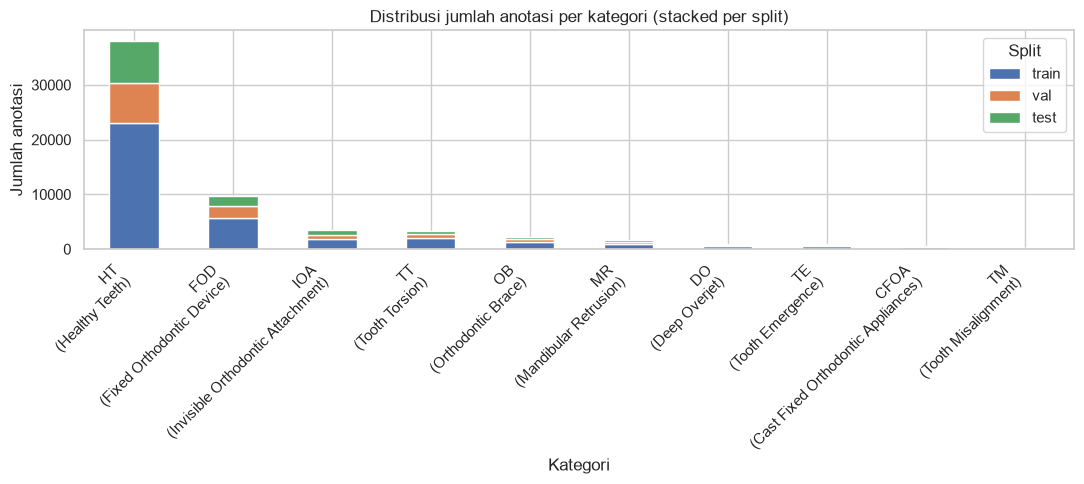

In [13]:
fig, ax = plt.subplots(figsize=(11, 5))
order = cat_counts.sort_values("total", ascending=False).index
cat_counts.loc[order, SPLITS].plot(kind="bar", stacked=True, ax=ax)
ax.set_title("Distribusi jumlah anotasi per kategori (stacked per split)")
ax.set_xlabel("Kategori")
ax.set_ylabel("Jumlah anotasi")
ax.set_xticklabels([f"{code}\n({CATEGORY_GLOSSARY[code]})" for code in order], rotation=45, ha="right")
ax.legend(title="Split")
plt.tight_layout()
plt.show()


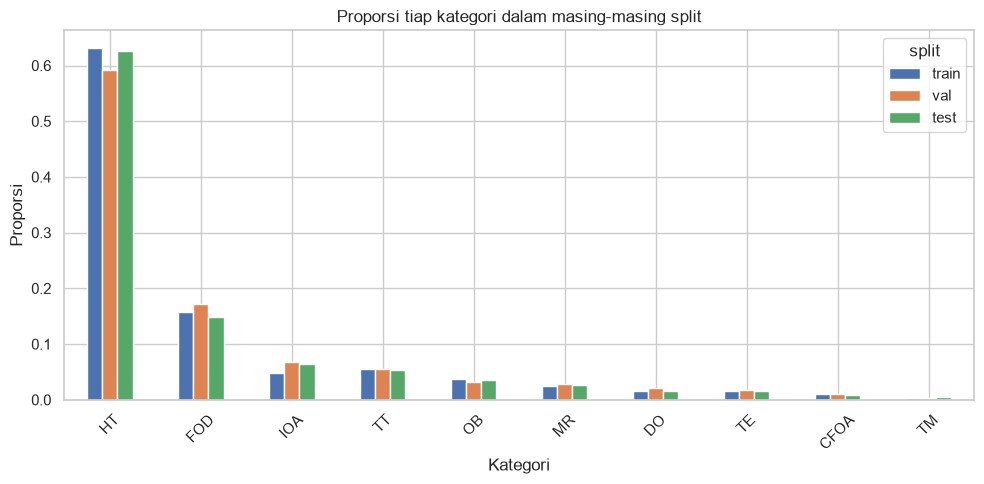

In [14]:
# Proporsi kategori per split (normalisasi) — untuk cek apakah distribusi kelas antar split mirip
cat_props = cat_counts[SPLITS].div(cat_counts[SPLITS].sum(axis=0), axis=1)
cat_props.loc[order].plot(kind="bar", figsize=(10, 5))
plt.title("Proporsi tiap kategori dalam masing-masing split")
plt.xlabel("Kategori")
plt.ylabel("Proporsi")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 6. Jumlah anotasi per gambar

Berapa banyak bounding box (temuan) rata-rata ditandai per foto?

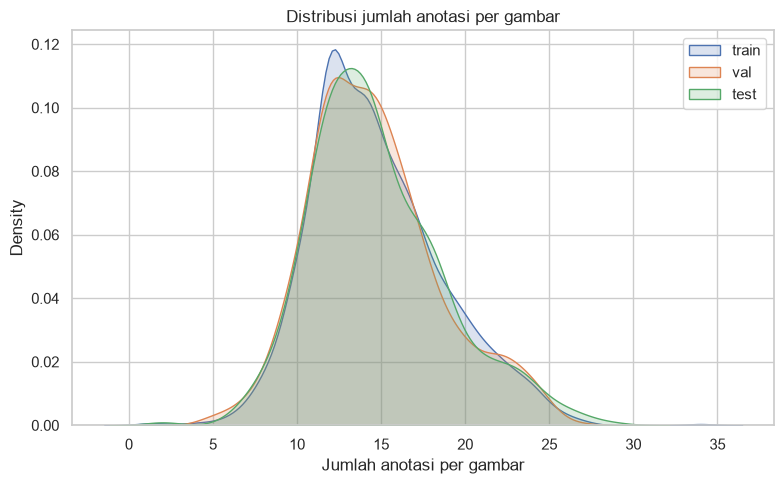

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,828.0,14.742754,4.011803,2.0,12.0,14.0,17.0,29.0
train,2478.0,14.709040,3.922504,1.0,12.0,14.0,17.0,34.0
val,857.0,14.564761,3.857063,5.0,12.0,14.0,17.0,27.0


In [15]:
anns_per_image = annotations_all.groupby(["split", "image_id"]).size().reset_index(name="n_anns")

fig, ax = plt.subplots(figsize=(8, 5))
for split in SPLITS:
    subset = anns_per_image[anns_per_image["split"] == split]["n_anns"]
    sns.kdeplot(subset, label=split, ax=ax, fill=True, alpha=0.2)
ax.set_title("Distribusi jumlah anotasi per gambar")
ax.set_xlabel("Jumlah anotasi per gambar")
plt.legend()
plt.tight_layout()
plt.show()

anns_per_image.groupby("split")["n_anns"].describe()


## 7. Statistik ukuran bounding box

Menambahkan kolom `bbox_w`, `bbox_h`, dan `area` (relatif terhadap ukuran gambar) untuk melihat seberapa besar/kecil temuan yang dianotasi, dan apakah ukurannya berbeda antar kategori.

In [16]:
bbox = annotations_all["bbox"].apply(pd.Series)
bbox.columns = ["bbox_x", "bbox_y", "bbox_w", "bbox_h"]
ann_bbox = pd.concat([annotations_all.reset_index(drop=True), bbox], axis=1)

img_dims = images_all.set_index("id")[["width", "height"]]
ann_bbox = ann_bbox.join(img_dims, on="image_id")
ann_bbox["bbox_w_rel"] = ann_bbox["bbox_w"] / ann_bbox["width"]
ann_bbox["bbox_h_rel"] = ann_bbox["bbox_h"] / ann_bbox["height"]
ann_bbox["area_rel"] = ann_bbox["bbox_w_rel"] * ann_bbox["bbox_h_rel"]

ann_bbox[["category_name", "bbox_w", "bbox_h", "area", "area_rel"]].groupby("category_name").describe().T


category_name           CFOA            DO           FOD            HT  \
bbox_w   count    608.000000   1014.000000   9684.000000  38044.000000   
         mean      79.250000     46.730769     51.817637     48.573546   
         std       50.579345     17.638676     18.858118     17.334487   
         min       14.000000     13.000000     12.000000      0.000000   
         25%       51.000000     34.000000     38.000000     36.000000   
         50%       69.000000     42.000000     49.000000     46.000000   
         75%       84.000000     61.000000     63.000000     60.000000   
         max      316.000000    102.000000    459.000000    125.000000   
bbox_h   count    608.000000   1014.000000   9684.000000  38044.000000   
         mean      60.827303     47.298817     57.432466     50.651430   
         std       24.222298     25.269026     15.742666     16.203971   
         min       25.000000      9.000000     18.000000      0.000000   
         25%       45.000000     27.000000     46.000000     39.000000   
         50%       56.000000     36.000000     56.000000     49.000000   
         75%       69.000000     70.000000     67.000000     61.000000   
         max      215.000000    114.000000    134.000000    128.000000   
area     count    608.000000   1014.000000   9684.000000  38044.000000   
         mean    5815.182566   2594.118343   3120.883932   2630.778809   
         std     7089.764053   2215.917140   1717.024271   1610.037692   
         min      493.000000    221.000000    306.000000      0.000000   
         25%     2442.500000    841.000000   1848.000000   1426.000000   
         50%     3829.500000   1462.000000   2808.000000   2255.000000   
         75%     5562.750000   4321.000000   4047.000000   3456.000000   
         max    51815.000000  11424.000000  28125.000000  13189.000000   
area_rel count    608.000000   1014.000000   9684.000000  38044.000000   
         mean       0.033307      0.014858      0.017875      0.015068   
         std        0.040608      0.012692      0.009834      0.009222   
         min        0.002824      0.001266      0.001753      0.000000   
         25%        0.013990      0.004817      0.010585      0.008168   
         50%        0.021934      0.008374      0.016083      0.012916   
         75%        0.031861      0.024749      0.023180      0.019795   
         max        0.296778      0.065433      0.161090      0.075542   

category_name           IOA           MR            OB           TE  \
bbox_w   count  3413.000000  1604.000000   2216.000000  1011.000000   
         mean     48.924700    43.632793     51.453971    41.065282   
         std      17.587911    13.921864     18.602960    11.711537   
         min       0.000000    11.000000     13.000000    16.000000   
         25%      36.000000    34.000000     37.000000    33.000000   
         50%      49.000000    42.000000     49.000000    40.000000   
         75%      61.000000    52.000000     64.000000    47.000000   
         max     110.000000   102.000000    249.000000    87.000000   
bbox_h   count  3413.000000  1604.000000   2216.000000  1011.000000   
         mean     53.869616    47.187656     55.167870    40.550940   
         std      13.222718    15.507117     16.424470    11.204142   
         min       2.000000     9.000000     25.000000    13.000000   
         25%      45.000000    36.000000     43.000000    33.000000   
         50%      53.000000    46.000000     53.000000    40.000000   
         75%      62.000000    56.000000     64.000000    48.000000   
         max     106.000000   106.000000    234.000000    95.000000   
area     count  3413.000000  1604.000000   2216.000000  1011.000000   
         mean   2741.146206  2146.241272   3020.763989  1731.120673   
         std    1389.526056  1197.880366   2073.704863   867.071814   
         min       0.000000   208.000000    425.000000   304.000000   
         25%    1728.000000  1320.000000   1689.750000  1155.00000

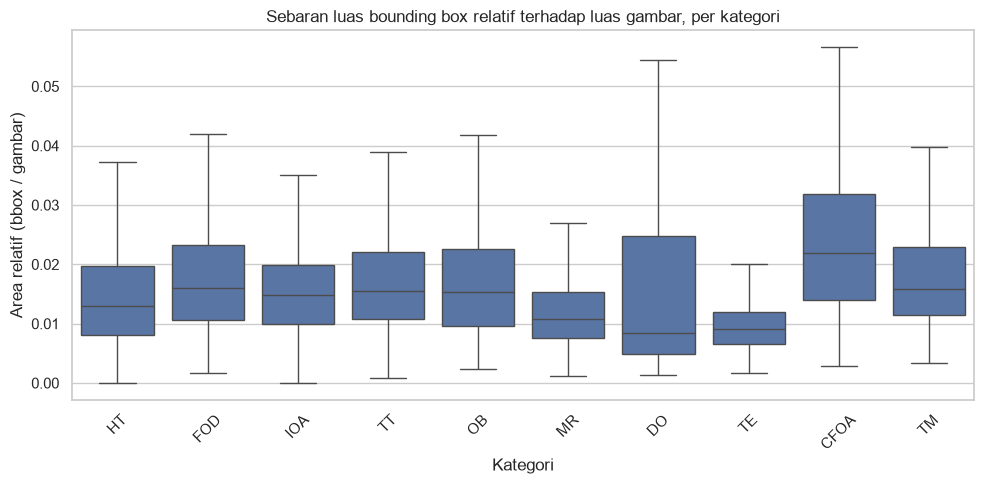

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=ann_bbox, x="category_name", y="area_rel", order=order, ax=ax, showfliers=False)
ax.set_title("Sebaran luas bounding box relatif terhadap luas gambar, per kategori")
ax.set_xlabel("Kategori")
ax.set_ylabel("Area relatif (bbox / gambar)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## 8. Struktur pasien & visit

Berapa kali rata-rata tiap pasien difoto (jumlah visit), dan berapa banyak gambar per visit?

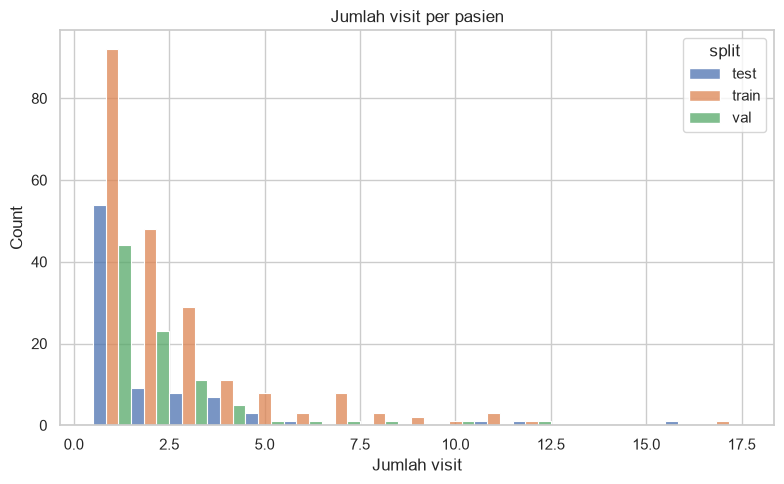

,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,85.0,2.164706,2.458450,1.0,1.0,1.0,3.0,16.0
train,210.0,2.604762,2.441855,1.0,1.0,2.0,3.0,17.0
val,89.0,2.146067,1.916143,1.0,1.0,2.0,2.0,12.0


In [18]:
visits_per_patient = (
    images_all.groupby(["split", "subfolder1"])["subfolder2"]
    .nunique()
    .reset_index(name="n_visits")
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=visits_per_patient, x="n_visits", hue="split", multiple="dodge", discrete=True, ax=ax)
ax.set_title("Jumlah visit per pasien")
ax.set_xlabel("Jumlah visit")
plt.tight_layout()
plt.show()

visits_per_patient.groupby("split")["n_visits"].describe()


In [19]:
images_per_visit = (
    images_all.groupby(["split", "subfolder1", "subfolder2"])
    .size()
    .reset_index(name="n_images")
)

print("Distribusi jumlah gambar per visit:")
images_per_visit.groupby("split")["n_images"].value_counts().sort_index()


Distribusi jumlah gambar per visit:


split  n_images
test   1            11
       2             4
       3            10
       4            17
       5           141
       6             1
train  1            26
       2            14
       3            31
       4            59
       5           414
       8             1
       10            2
val    1             9
       2             7
       3            14
       4            19
       5           140
       6             1
       10            1
Name: count, dtype: int64

## 9. Visualisasi sampel gambar dengan bounding box

Mengambil beberapa gambar acak dari `train` dan menampilkan bounding box beserta label kategorinya, untuk sanity-check kualitas anotasi.

In [20]:
def get_image_path(split, row):
    return ROOT / split / row["subfolder1"] / row["subfolder2"] / row["file_name"]


def plot_image_with_boxes(split, image_id, ax):
    img_row = images[split].set_index("id").loc[image_id]
    img_path = get_image_path(split, img_row)
    img = Image.open(img_path)
    ax.imshow(img)

    boxes = annotations[split][annotations[split]["image_id"] == image_id]
    for _, box in boxes.iterrows():
        x, y, w, h = box["bbox"]
        rect = patches.Rectangle((x, y), w, h, linewidth=1.5, edgecolor="red", facecolor="none")
        ax.add_patch(rect)
        ax.text(x, max(y - 3, 0), box["category_name"], color="white", fontsize=7,
                 bbox=dict(facecolor="red", alpha=0.6, pad=0.5))
    ax.set_title(f"{split} | image_id={image_id}", fontsize=9)
    ax.axis("off")


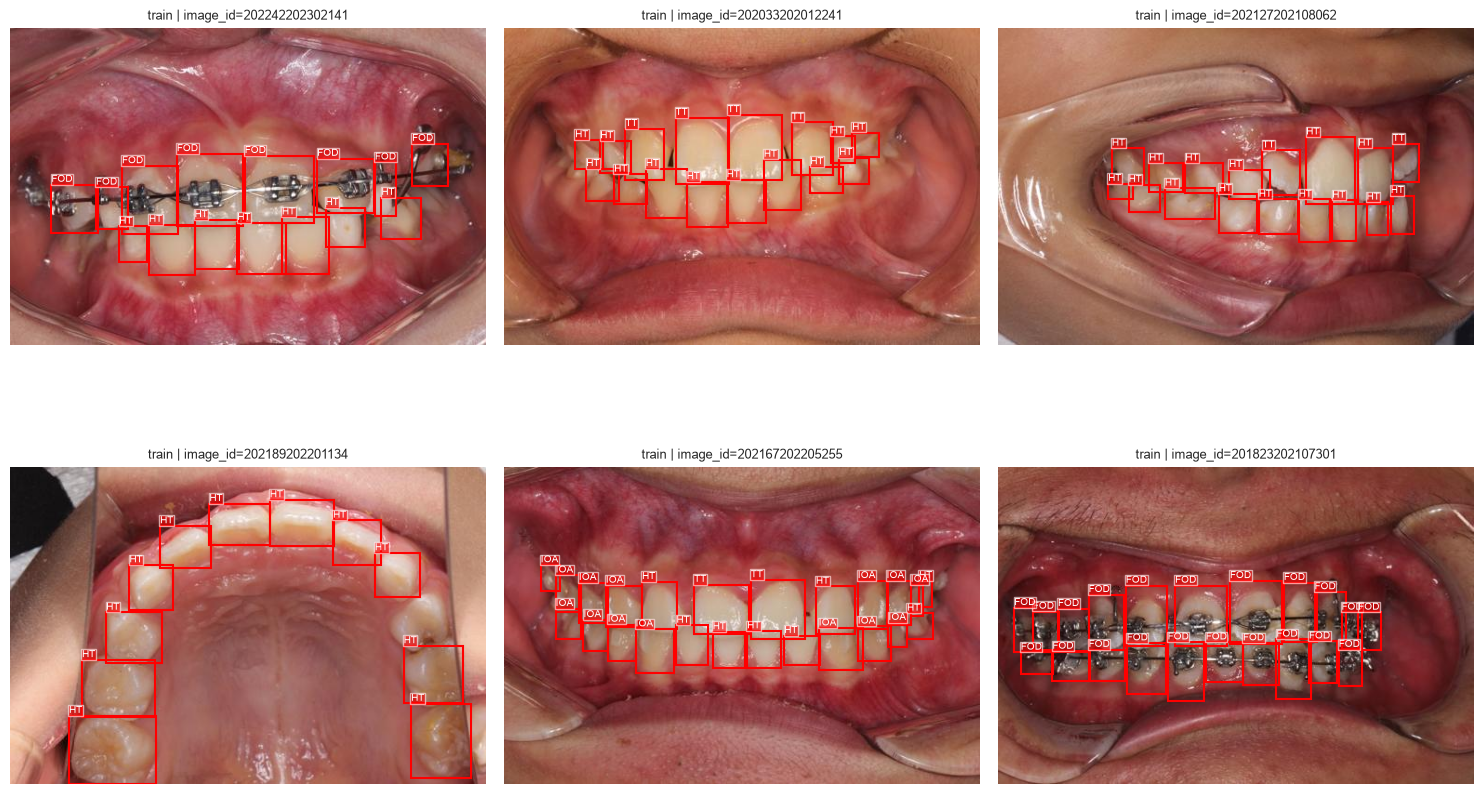

In [21]:
sample_image_ids = images["train"]["id"].sample(6, random_state=1).tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for image_id, ax in zip(sample_image_ids, axes.ravel()):
    plot_image_with_boxes("train", image_id, ax)
plt.tight_layout()
plt.show()


### 9.1 Satu visit lengkap (5 sudut foto)

Tiap visit biasanya berisi beberapa foto intraoral dari sudut berbeda (mis. frontal, kanan, kiri, oklusal atas, oklusal bawah). Kita tampilkan satu visit lengkap untuk melihat variasi sudut pengambilan.

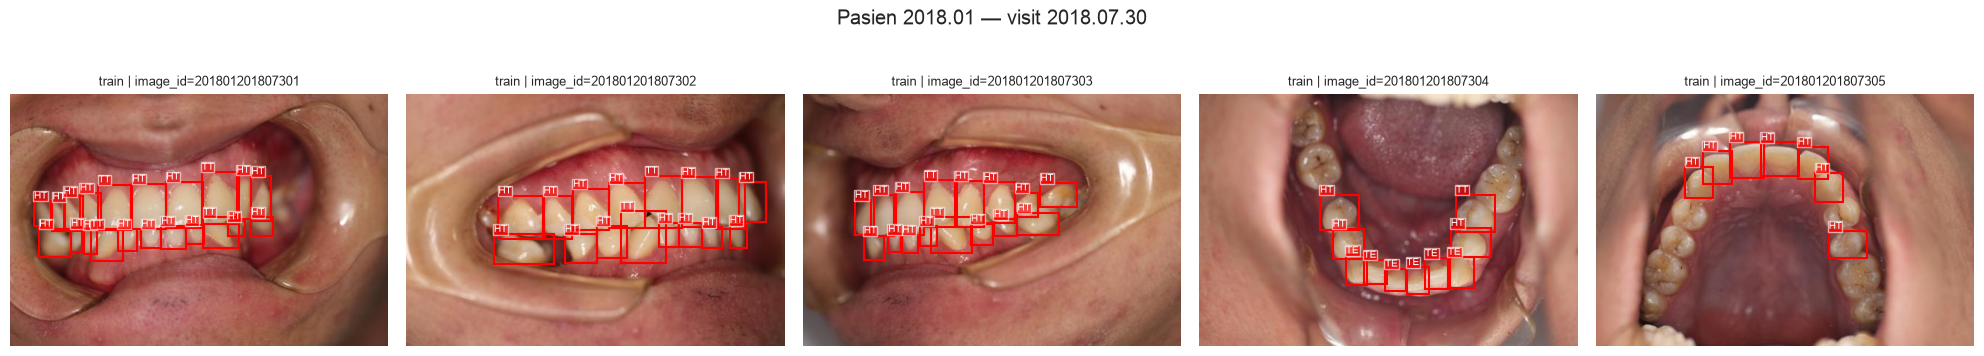

In [22]:
example_patient, example_visit = images["train"][["subfolder1", "subfolder2"]].iloc[0]
visit_images = images["train"][
    (images["train"]["subfolder1"] == example_patient) &
    (images["train"]["subfolder2"] == example_visit)
]

n = len(visit_images)
fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
if n == 1:
    axes = [axes]
for image_id, ax in zip(visit_images["id"], axes):
    plot_image_with_boxes("train", image_id, ax)
fig.suptitle(f"Pasien {example_patient} — visit {example_visit}")
plt.tight_layout()
plt.show()


## 10. Catatan / temuan awal

**Ukuran & integritas data**
- Total 4166 gambar, 61138 anotasi, 384 pasien unik, split train/val/test 2481/857/828 gambar (210/89/85 pasien).
- Tidak ada pasien yang bocor antar split (train/val/test benar-benar terpisah per pasien) — aman dari data leakage.
- Tidak ada file gambar yang hilang, tidak ada anotasi yatim. Ada 3 gambar di train tanpa anotasi sama sekali (bisa dicek manual, kemungkinan foto kosong/gagal capture).
- Ukuran gambar seragam 512×341 di seluruh dataset — tidak perlu strategi resize khusus.

**Class imbalance — ini yang paling perlu diperhatikan sebelum training**
- `HT` (Healthy Teeth) mendominasi ~62% dari semua anotasi (38044/61138), `FOD` (Fixed Orthodontic Device) ~16% (9684) — dua kelas ini saja sudah ~78% dari total.
- Di ujung lain, `TM` (Tooth Misalignment) cuma 180 instance (~0.3%) dan `CFOA` 608 (~1%) — rasio HT:TM sekitar 211:1.
- Proporsi antar split (train/val/test) relatif konsisten, jadi imbalance-nya bukan artefak split, tapi memang karakteristik data.
- Implikasi: wajib pakai class weighting / oversampling minority class / focal loss saat training, kalau tidak model akan bias ke HT dan FOD.

**Dua "jenis" kelas yang tercampur dalam satu skema label**
- Kelas terkait **alat/perawatan ortodontik** (kondisi buatan, bukan kelainan alami): `OB` (Orthodontic Brace), `IOA` (Invisible Orthodontic Attachment), `CFOA` (Cast Fixed Orthodontic Appliances), `FOD` (Fixed Orthodontic Device).
- Kelas terkait **kelainan/kondisi gigi-rahang**: `TT` (Tooth Torsion), `DO` (Deep Overjet), `TM` (Tooth Misalignment), `MR` (Mandibular Retrusion).
- Kelas **kondisi normal/perkembangan**: `HT` (Healthy Teeth), `TE` (Tooth Emergence).
- Ini perlu dipikirkan lagi di tahap desain task: apakah mau diklasifikasi jadi satu skema 10-kelas seperti sekarang, atau dipecah jadi sub-task terpisah (mis. deteksi alat vs deteksi kelainan) yang mungkin lebih bermakna secara klinis.

**Ukuran bounding box**
- Rata-rata bbox kecil relatif terhadap gambar, sekitar 1-2% dari luas foto untuk sebagian besar kelas.
- `CFOA` menonjol dengan bbox jauh lebih besar (rata-rata ~3.3% luas gambar, bisa sampai ~30%) — masuk akal karena kawat gigi cor/cast biasanya menutupi area gigi yang lebih luas dibanding temuan per-gigi lainnya.
- Bbox kecil ini penting kalau nanti crop per-objek untuk classifier (CNN/EfficientNet) — perlu padding/context margin di sekitar box, jangan crop terlalu ketat.

**Struktur pasien & visit**
- Rata-rata tiap visit berisi 5 foto (sesuai set foto ortodontik standar: frontal + kanan + kiri + oklusal atas + oklusal bawah) — ini pola paling umum di seluruh split.
- Ada variasi: sebagian visit cuma 1-4 foto (mungkin sesi tidak lengkap), dan segelintir sampai 8-10 foto (kemungkinan foto duplikat/ulang).
- Rata-rata pasien punya ~2.6 visit (547 visit / 210 pasien di train) — dataset bersifat longitudinal, berpotensi dipakai untuk analisis progres perawatan antar waktu kalau dibutuhkan nanti, bukan cuma snapshot tunggal.

**Yang sudah diverifikasi**
- Mismatch angka Table 1 paper OMNI vs section 5 notebook ini **sudah dicek dan cocok**: angka paper = jumlah gambar unik yang punya minimal satu temuan kategori itu (`nunique(image_id)`), bukan jumlah instance bounding box. Sudah diverifikasi cocok 1:1 persis untuk semua 10 kategori — lihat catatan di section 2. Bukan indikasi versi/split dataset yang berbeda.

**Yang masih perlu diverifikasi**
- 3 gambar tanpa anotasi di train belum dicek manual — perlu dipastikan bukan gambar korup/placeholder.
